| Regression Type                  | Use When…                                                                         |
| -------------------------------- | --------------------------------------------------------------------------------- |
| **Simple Linear Regression**     | One input feature, linear relationship                                            |
| **Multiple Linear Regression**   | Multiple input features, linear relationship                                      |
| **Polynomial Regression**        | Relationship is nonlinear but continuous                                          |
| **Support Vector Regression**    | Data is small, high-dimensional, or non-linear                                    |
| **Decision Tree Regression**     | Data has complex, non-linear relationships with potential thresholds              |
| **Random Forest Regression**     | Similar to above, but with more robustness and less overfitting                   |
| **Gradient Boosting Regression** | When you want more accuracy than random forest, and are okay with slower training |
| **XGBoost Regression**           | Large datasets, need regularization, speed, or top competition performance        |


##Python code examples and reiteration

this is just a way to further reiterate and remind all the way to the beginning of this whole project that specifically related to regression

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

startups_df = pd.read_csv("/home/ducanh19082007/Quantitative_Finance_Self_Learning/Data/0.Data_Sets/50_Startups.csv")

# Apply LabelEncoder per column
for col in startups_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    startups_df[col] = le.fit_transform(startups_df[col])

startups_df

/tmp/ipykernel_115557/3535979118.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in startups_df.select_dtypes(include='object').columns:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,2,192261.83
1,162597.70,151377.59,443898.53,0,191792.06
2,153441.51,101145.55,407934.54,1,191050.39
3,144372.41,118671.85,383199.62,2,182901.99
4,142107.34,91391.77,366168.42,1,166187.94
5,131876.90,99814.71,362861.36,2,156991.12
6,134615.46,147198.87,127716.82,0,156122.51
7,130298.13,145530.06,323876.68,1,155752.60
8,120542.52,148718.95,311613.29,2,152211.77
9,123334.88,108679.17,304981.62,0,149759.96


In [21]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

x = startups_df.drop(["Profit"], axis=1)
y = startups_df["Profit"]
x_train, x_test, y_train, y_test  = train_test_split(x,y,test_size=0.2, random_state=42)

XGB_modeling_1 = xgb.XGBRegressor()
XGB_modeling_1.fit(x_train, y_train)

XGB_predicting = XGB_modeling_1.predict(x_test)

print("predicting stuffs", XGB_predicting, "real testing data\n", y_test)

predicting stuffs [125757.78   79436.7    98814.49   43040.566 133134.45   26074.123
 109426.68   99632.38   99632.19  112432.66 ] real testing data
 13    134307.35
39     81005.76
30     99937.59
45     64926.08
17    125370.37
48     35673.41
26    105733.54
25    107404.34
32     97427.84
19    122776.86
Name: Profit, dtype: float64


In [22]:
#ACCURACY SET UP

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error

def symmetric_mean_absolute_percentage_error_execution(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    smape_value = np.mean(diff / denominator) * 100
    return smape_value

def getScores_ultimatium(y_test, y_pred):
  mean_absolute_error_result = mean_absolute_error(y_test, y_pred)
  mean_squared_error_result = mean_squared_error(y_test, y_pred)
  symmetric_mean_absolute_percentage_error_execution_result = symmetric_mean_absolute_percentage_error_execution(y_test, y_pred)
  root_mean_squared_error_result = root_mean_squared_error(y_test, y_pred)
  r2_score_result = r2_score(y_test, y_pred)
  mean_bias_error_result = (abs(y_pred - y_test))/(y_test*len(y_test))
  mean_absolute_percentage_error_result = mean_absolute_percentage_error(y_test, y_pred)
  results = {
      "Mean Absolute Error": mean_absolute_error_result,
      "Mean Squared Error": mean_squared_error_result,
      "Symmetric Mean Absolute Percentage Error": symmetric_mean_absolute_percentage_error_execution_result,
      "Root Mean Squared Error": root_mean_squared_error_result,
      "r2_score": r2_score_result,
      "Mean Bias Error": sum(mean_bias_error_result),
      "Mean Absolute Percentage Error": mean_absolute_percentage_error_result
  }
  return results

In [23]:
#REGRESSION SET UP

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

startups_df = pd.read_csv("/home/ducanh19082007/Quantitative_Finance_Self_Learning/Data/0.Data_Sets/50_Startups.csv")

LabelEncoderer_Model_Example = LabelEncoder()

for i in startups_df.columns:
  if startups_df[i].dtype == "object":
    startups_df[i] = LabelEncoderer_Model_Example.fit_transform(startups_df[i])

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state = 42)

def for_everything_except_lm_and_xgb(x_train, x_test, y_train, y_test,
                                     MachineLearning_model_name):
  MachineLearning_model = MachineLearning_model_name()
  MachineLearning_model.fit(x_train, y_train)
  y_predictive = MachineLearning_model.predict(x_test)

  if MachineLearning_model_name == DecisionTreeRegressor:
    plt.figure(figsize=(30, 7))
    plot_tree(
      MachineLearning_model,
      feature_names=["R&D Spend", "Administration", "Marketing Spend", "State"],
      filled=True,
      fontsize=10,
      max_depth=2
    )
    plt.title("Decision Tree Structure")

  plt.show()
  return getScores_ultimatium(y_test, y_predictive),

In [24]:
##Simple linear Regression
for_everything_except_lm_and_xgb(x_train, x_test, y_train, y_test, LinearRegression)

({'Mean Absolute Error': 6979.17574672138,
  'Mean Squared Error': 80929465.49097767,
  'Symmetric Mean Absolute Percentage Error': np.float64(10.075499915872403),
  'Root Mean Squared Error': 8996.080562721616,
  'r2_score': 0.9000614254946404,
  'Mean Bias Error': 0.10314132258040647,
  'Mean Absolute Percentage Error': 0.10314132258040647},)

In [25]:
#Support Vector Regression
for_everything_except_lm_and_xgb(x_train, x_test, y_train, y_test, SVR)

({'Mean Absolute Error': 22844.87016361027,
  'Mean Squared Error': 955494707.0536398,
  'Symmetric Mean Absolute Percentage Error': np.float64(25.434402021480896),
  'Root Mean Squared Error': 30911.077416577373,
  'r2_score': -0.17992598111255997,
  'Mean Bias Error': 0.38039958674277796,
  'Mean Absolute Percentage Error': 0.38039958674277796},)

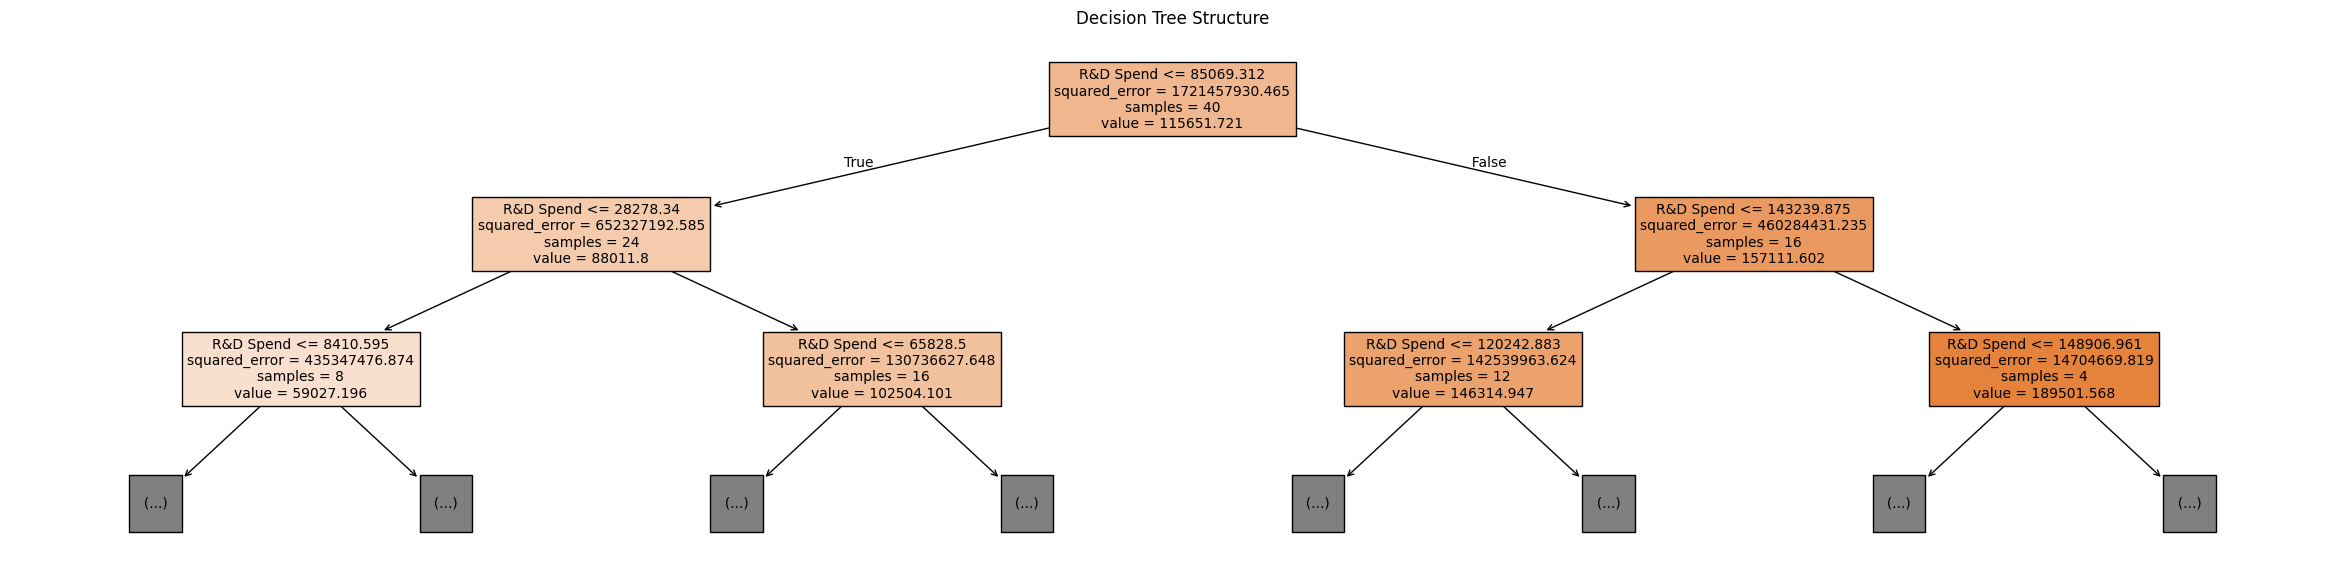

({'Mean Absolute Error': 8138.886999999997,
  'Mean Squared Error': 117449338.2626899,
  'Symmetric Mean Absolute Percentage Error': np.float64(11.279253754718175),
  'Root Mean Squared Error': 10837.404590707589,
  'r2_score': 0.8549635862369611,
  'Mean Bias Error': 0.11296577605649859,
  'Mean Absolute Percentage Error': 0.1129657760564986},)

In [26]:
#Decision Tree Regression
for_everything_except_lm_and_xgb(x_train, x_test, y_train, y_test, DecisionTreeRegressor)

In [27]:
for_everything_except_lm_and_xgb(x_train, x_test, y_train, y_test, xgb.XGBRegressor)

({'Mean Absolute Error': 7450.425523437501,
  'Mean Squared Error': 89412571.44249564,
  'Symmetric Mean Absolute Percentage Error': np.float64(10.927491707304435),
  'Root Mean Squared Error': 9455.82209236699,
  'r2_score': 0.8895857660913647,
  'Mean Bias Error': 0.09765330774462978,
  'Mean Absolute Percentage Error': 0.0976533077446298},)